In [1]:
%load_ext autoreload
%autoreload 2

# Visualise sequence mutations for Thesis

Dataset overview:

1. Dataset `2024_11_27_145142` was resimulated with different starting copy numbers in the following: 
Datasets:
- Original: `2024_11_27_145142`
- Starting copies = 100, dt0 = 0.0001: `2026_01_12__18_50_13`
- Starting copies = 200, dt0 = 0.0001: `2026_01_14__22_38_47`
- Starting copies = 100, dt0 = 0.01: `2026_01_15__15_43_12`

2. Dataset `2024_11_21_160955` was resimulated as dataset `2025_02_11__13_56_51`. 

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

from common import set_theme, add_sample_names
from synbio_morpher.utils.results.analytics.timeseries import calculate_adaptation

PALETTE = 'viridis'

set_theme()

In [3]:
'data/raw/summarise_simulation/2024_11_21_160955/tabulated_mutation_info.csv'
'data/simulate_circuits/2026_01_12__18_50_13/config.json'
'data/simulate_circuits/2026_01_12__18_50_13/analytics.json'

'data/simulate_circuits/2026_01_12__18_50_13/analytics.json'

In [4]:
fn_og = '../data/raw/summarise_simulation/2024_11_27_145142/tabulated_mutation_info.csv'
fn_resim = '../notebooks/data/simulate_circuits/2026_01_12__18_50_13/analytics.json'
data = pd.read_csv(fn_og)
df_resim = pd.read_json(fn_resim).drop(columns='RMSE')
df_resim = df_resim.explode(df_resim.columns.to_list()).reset_index(drop=True)
cols_resim = list(df_resim.columns)

In [5]:
names_species_input = data['sample_name'].unique()
n_species_input = len(names_species_input)
n_species_total = int(len(df_resim) / len(data) * n_species_input)

df_resim = add_sample_names(df_resim, names_species_input, n_species_input, n_species_total)
data[cols_resim] = df_resim.query('sample_name in ["RNA_0", "RNA_1", "RNA_2"]')[cols_resim].values.astype(np.float32)
del df_resim

data.rename(columns={'mutation_num': 'N mutations'}, inplace=True)
data['Log sensitivity'] = np.log10(data['sensitivity'])
data['Log precision'] = np.log10(data['precision'])
data['adaptation'] = calculate_adaptation(np.array(data['sensitivity']), np.array(data['precision']), alpha=2)

In [6]:
for k in ['Log sensitivity', 'Log precision', 'adaptation']:
    # data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index()[k]
    data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]
    data[f'{k} ratio'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x/x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]

# Loss of adaptable circuits

In [27]:
filt_adapt = (data['Log sensitivity'] > -1) & (data['Log precision'] > 0.5)
filt_adapt_strict = (data['Log sensitivity'] >= 0.) & (data['Log precision'] >= 1.0)
filt_m = data['N mutations'] > 0
filt_samp = data['sample_name'] == 'RNA_2'


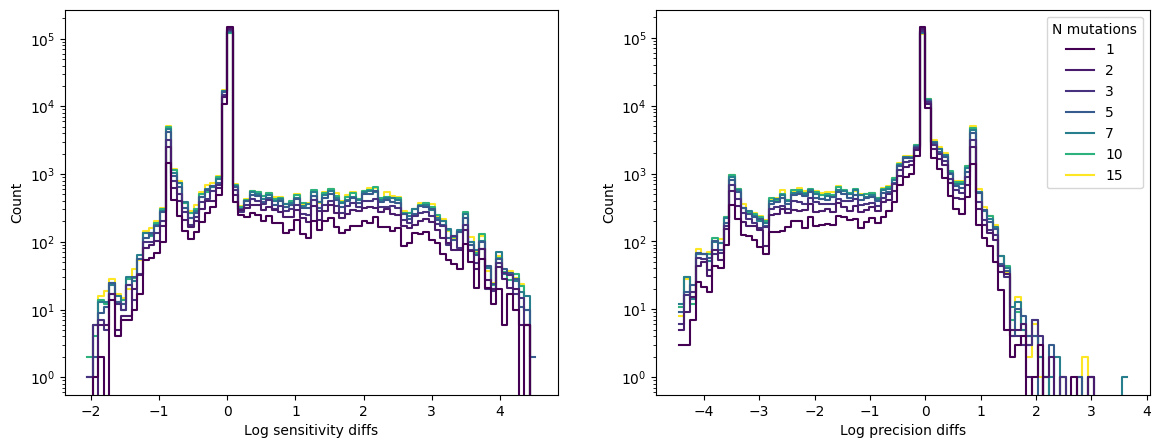

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data[filt_adapt & filt_m], x=f'Log sensitivity diffs', hue='N mutations',
            palette=PALETTE, bins=80, fill=False, element='step', ax=axs[0], legend=False)
axs[0].set_yscale('log')
sns.histplot(data[filt_adapt & filt_m], x=f'Log precision diffs', hue='N mutations',
            palette=PALETTE, bins=80, fill=False, element='step', ax=axs[1], legend=True)
axs[1].set_yscale('log')

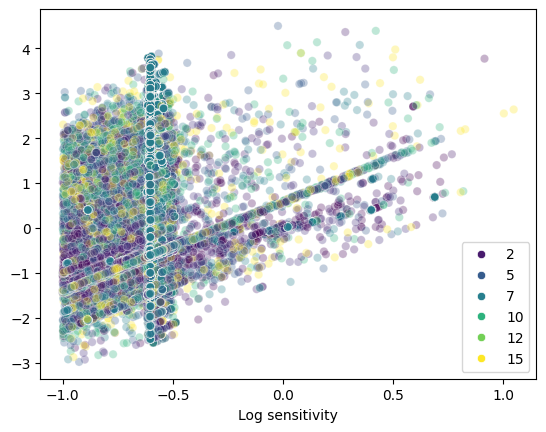

In [11]:
g = sns.scatterplot(data[filt_adapt & filt_m], x=f'Log sensitivity', 
                    y=data[filt_adapt & filt_m]['Log sensitivity diffs'].values + 
                    data[filt_adapt & filt_m]['Log sensitivity'].values, 
                hue='N mutations', palette=PALETTE, alpha=0.3)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title='Log sensitivity mutated')
for line in g.legend().get_lines():
    line.set_alpha(1.0)

# Sequence mutation in retained adaptable circuits

In [12]:
import ast

data['mutation_type_list'] = data['mutation_type'].apply(ast.literal_eval)
data['mutation_positions_list'] = data['mutation_positions'].apply(ast.literal_eval)

In [13]:
cols = ['mutation_type_list', 'mutation_positions_list', 'N mutations', 'circuit_name', 'mutation_name',
        'adaptation diffs', 'Log sensitivity diffs', 'Log precision diffs', 
        'adaptation ratio', 'Log sensitivity ratio', 'Log precision ratio', 
        'adaptation', 'sensitivity', 'precision', 'Log sensitivity', 'Log precision']
df_mutations = data[filt_samp][cols].explode('mutation_type_list').reset_index()
df_mutations['mutation_positions_list'] = data[filt_samp & filt_m][cols].explode('mutation_positions_list').reset_index()['mutation_positions_list']

Text(0, 0.5, 'Adaptation difference (mutated - original)')

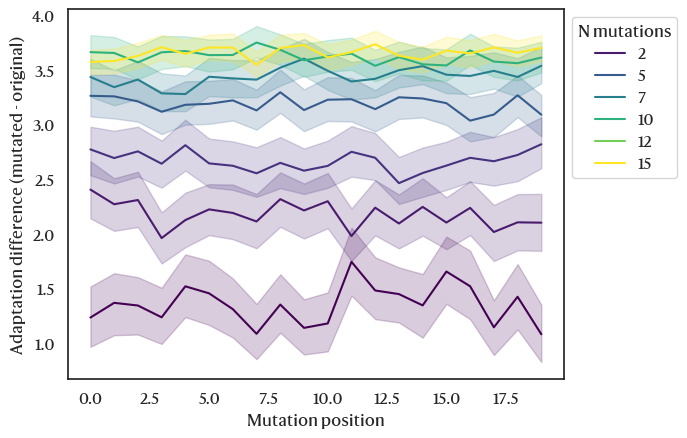

In [20]:
g = sns.lineplot(df_mutations[(df_mutations['Log sensitivity'] >= -1) & (df_mutations['Log precision'] >= 0) 
                          & (df_mutations['N mutations'] > 0)],
                          x='mutation_positions_list', y='adaptation diffs',
                          hue='N mutations', palette=PALETTE, estimator='mean') #, errorbar='sd')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.xlabel('Mutation position')
plt.ylabel('Adaptation difference (mutated - original)')

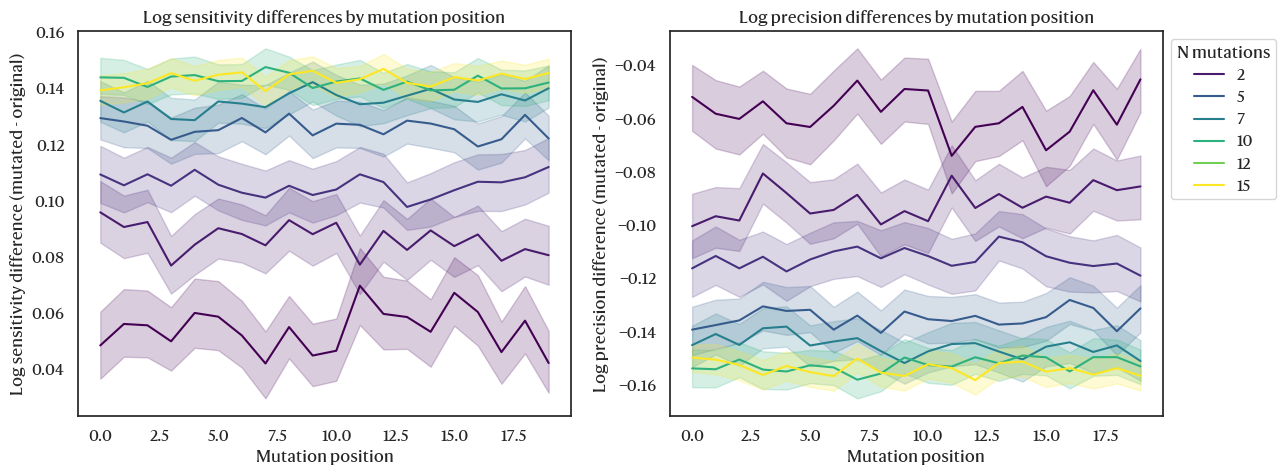

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for i, c in enumerate(['Log sensitivity', 'Log precision']):
    is_legend = (i == 1)
    g = sns.lineplot(df_mutations[(df_mutations['Log sensitivity'] >= -1) & (df_mutations['Log precision'] >= 0) 
                              & (df_mutations['N mutations'] > 0)],
                              x='mutation_positions_list', y=f'{c} diffs',
                              hue='N mutations', palette=PALETTE, ax=axs[i],
                              legend=is_legend)
    if is_legend:
        sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    axs[i].set_xlabel('Mutation position')
    axs[i].set_ylabel(f'{c.capitalize()} difference (mutated - original)')
    axs[i].set_title(f'{c.capitalize()} differences by mutation position')

Now looking at strictly adaptable circuits

In [47]:
df_mutations['mutation_idx'] = df_mutations['mutation_name'].apply(lambda x: int(x.split('-')[-1]) if x != 'ref_circuit' else 0)

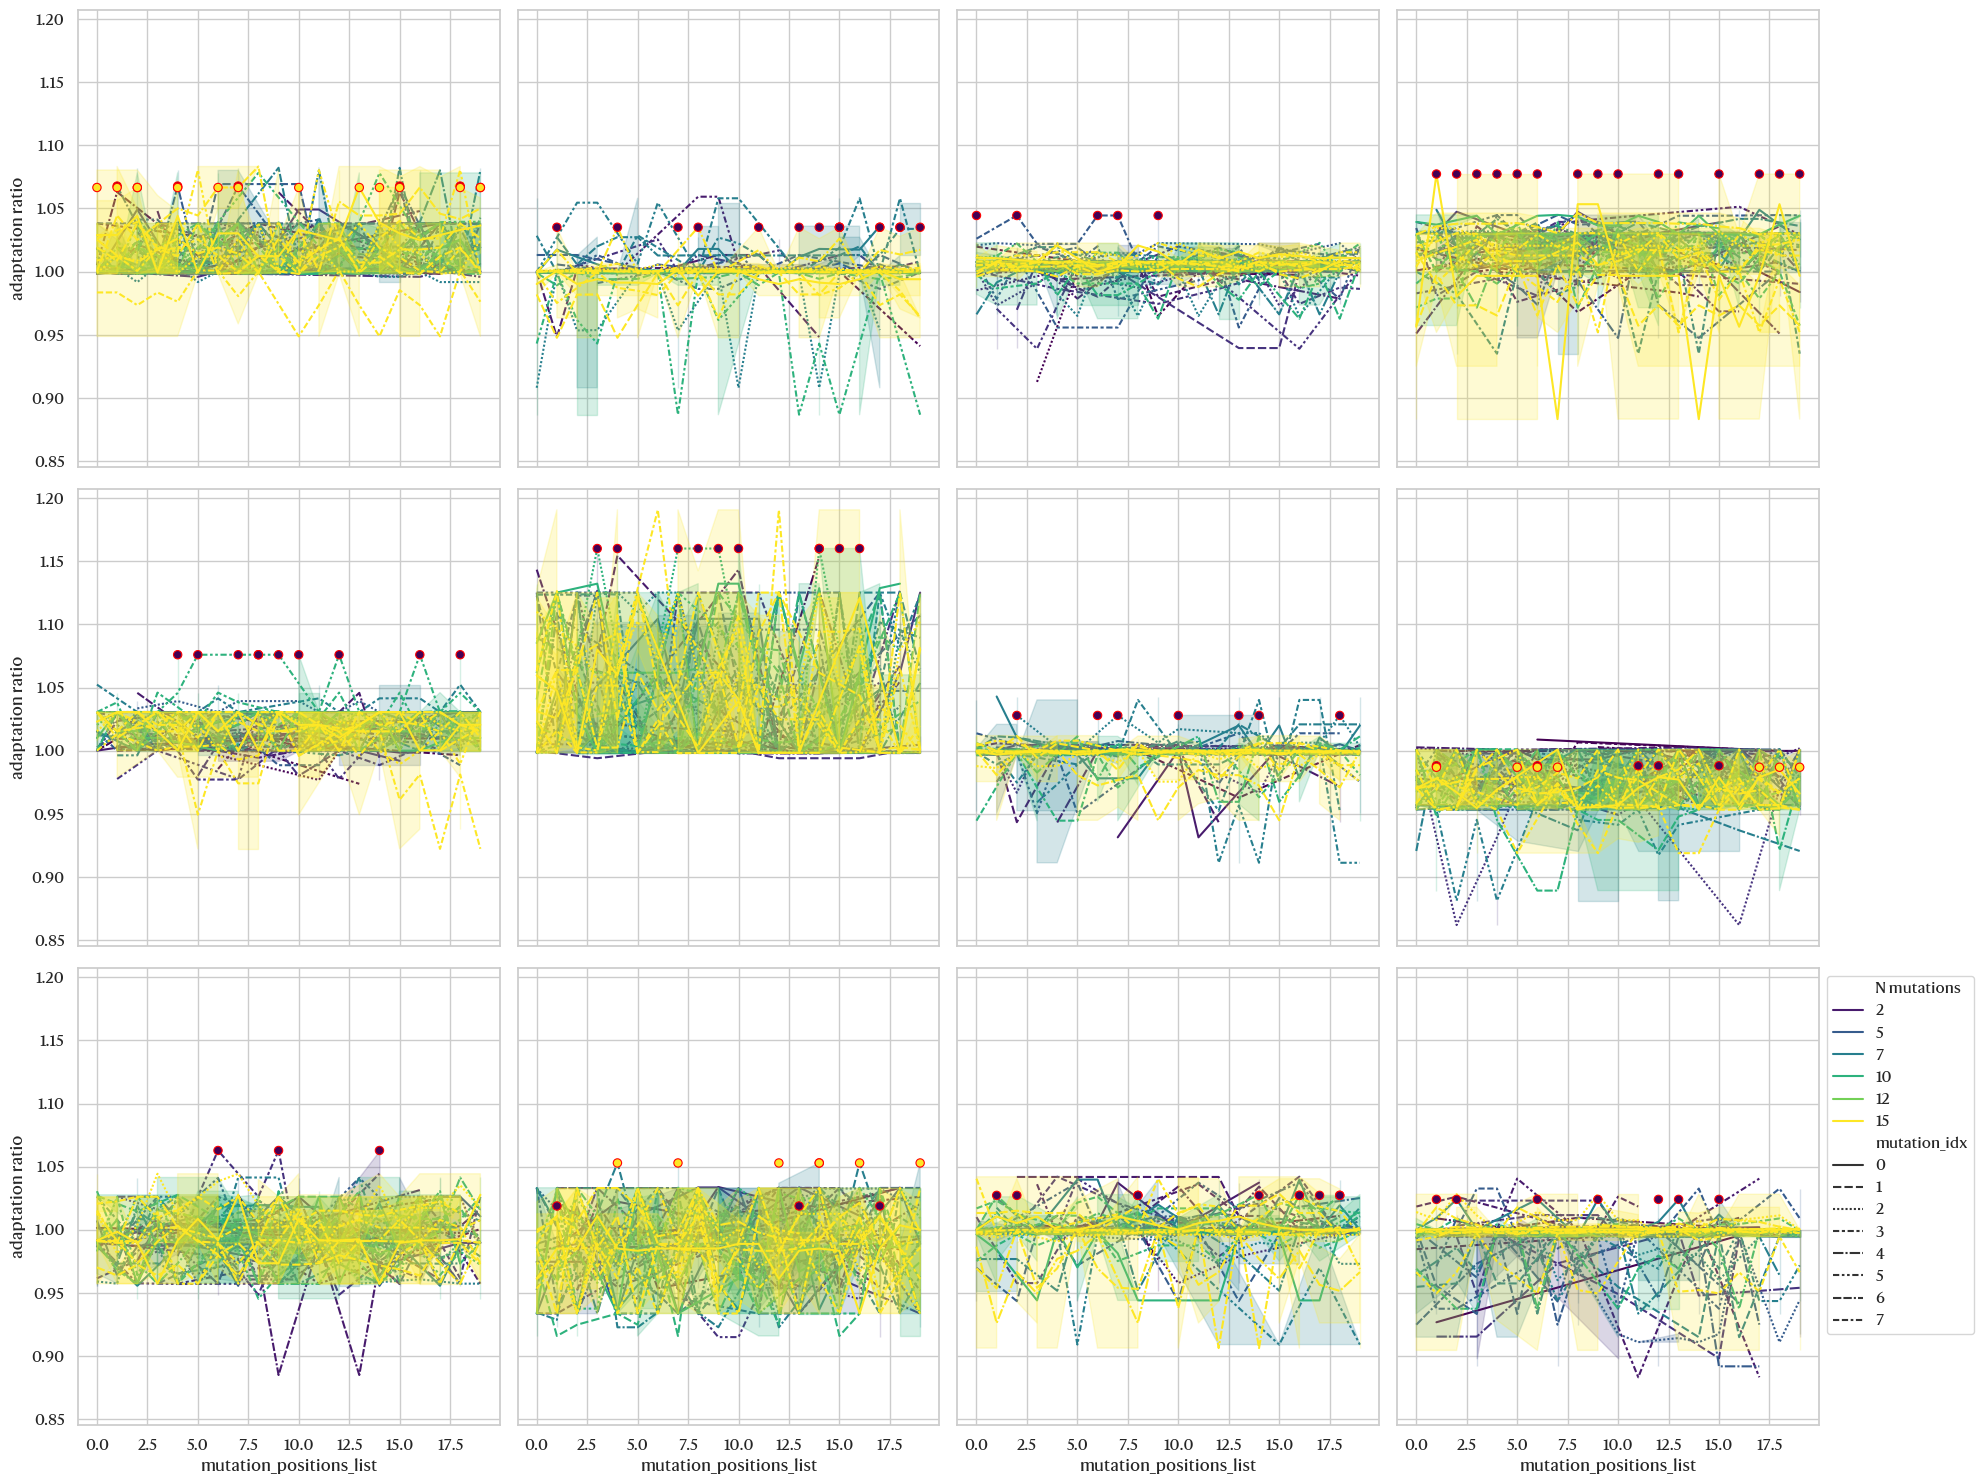

In [79]:
circuits_adaptable = data[filt_samp & filt_adapt_strict]['circuit_name'].unique()
circuits_adaptable = circuits_adaptable[:12]

filt_muts_adapt = (df_mutations['Log sensitivity'] >= 0.) & (df_mutations['Log precision'] >= 1.0)

nrows = 3 # int(np.ceil(np.sqrt(len(circuits_adaptable))))
ncols = 4 # int(np.ceil(np.sqrt(len(circuits_adaptable))))
fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), sharex=True, sharey=True)
for i, circ in enumerate(circuits_adaptable):
    filt_muts_circ = df_mutations['circuit_name'] == circuits_adaptable[i]
    is_legend = i == len(circuits_adaptable) - 1
    g = sns.lineplot(df_mutations[filt_muts_circ & (df_mutations['N mutations'] > 0)],
                x='mutation_positions_list', y='adaptation ratio', 
                style='mutation_idx',
                hue='N mutations', palette=PALETTE,
                estimator='mean', ax=axs.flat[i], legend=is_legend,
                )
    if is_legend:
        sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
    gg = sns.scatterplot(df_mutations[filt_muts_circ & filt_muts_adapt],
                    x='mutation_positions_list', y='adaptation ratio', 
                    hue='N mutations', palette=PALETTE,
                    ax=axs.flat[i], legend=False) #, color='black', alpha=1.0)
    sc = axs.flat[i].collections[-1]
    sc.set_edgecolor('red')
    sc.set_linewidth(0.8)

    for artist in gg.lines:
        artist.set_zorder(10000)
    for artist in gg.collections:
        artist.set_zorder(10000)

plt.tight_layout()

# colors = sns.color_palette(PALETTE, n_colors=df_mutations['N mutations'].nunique())
# for i, m in enumerate(df_mutations['N mutations'].unique()):
#     g = sns.lineplot(df_mutations[filt_muts_circ
#                     & (df_mutations['N mutations'] == m)],
#                     x='mutation_positions_list', y='adaptation ratio',
#                     hue='mutation_type_list',
#                     style='mutation_idx', color=colors[i], estimator='mean',
#                     legend=i==1) #, errorbar='sd')
# sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
